<a href="https://colab.research.google.com/github/NickS785/CTAFlow/blob/v2/notebooks/colab_multi_asset_wspr_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Asset WSPR Training & Optuna Optimization

This notebook trains and optimizes the **MultiAssetWSPR** model using Optuna hyperparameter tuning on multiple tickers simultaneously.

## Model Architecture: MultiAssetWSPR
The model processes data through six parallel paths:
1. **Windowed Summary**: LSTM over summary embeddings across W days
2. **Windowed Profile**: LSTM over profile embeddings across W days  
3. **Recent Raster**: RasterResNet on most recent day's rasterized VPIN
4. **Recent Sequential**: IntradayRNN on most recent day's intraday sequence
5. **Recent Spatial Fusion**: Fused profile + raster for current market state
6. **Meta Modality**: Encodes ticker identity, asset class, and calendar features

## Multi-Ticker Training
- Trains on multiple tickers (e.g., HE + LE livestock futures)
- Automatic schema alignment for summary features
- Ticker metadata encoding via MetaModalityEncoder
- Date-aligned train/val splits across tickers

## Optimization Strategy
- Small trial count (<30) for efficiency
- Robust parameter ranges based on single-ticker experiments
- TPE sampler with early pruning
- ProfitWeightedCE loss for trading-aware optimization

## 1. Environment Setup

In [45]:
# Mount Google Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab - skipping drive mount")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
# Add CTAFlow to path (Colab only)
if IN_COLAB:
    import sys
    %cd /content/drive/MyDrive/CTAEnv/
    %cd CTAFlow
    !git pull
    %cd ..
    sys.path.insert(0, '/content/drive/MyDrive/CTAEnv/CTAFlow/')
    sys.path.insert(1, '/content/drive/MyDrive/CTAEnv/SierraPy')
    !pip install -e SierraPy -q
    !pip install -e CTAFlow -q
    !pip install optuna -q
else:
    print("Running locally - ensure CTAFlow and optuna are installed")

/content/drive/MyDrive/CTAEnv
/content/drive/MyDrive/CTAEnv/CTAFlow
Already up to date.
/content/drive/MyDrive/CTAEnv
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sierrapy (pyproject.toml) ... done
  Installing build dependencies ... canceledERROR: Operation cancelled by user


In [47]:
import json
import warnings
from datetime import time, timedelta
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"Optuna version: {optuna.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
Optuna version: 4.7.0
CUDA available: True
CUDA device: NVIDIA L4


In [48]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


## 2. Multi-Ticker Configuration

In [49]:
from CTAFlow.data.classifications_reference import get_commodities_by_category

# --- Tickers to train on ---
TICKERS = ['HE', 'LE']  # Livestock futures

# --- Session configuration (livestock) ---
SESSION_END = time(13, 0)      # 1:00 PM CST
SESSION_OPEN = time(8, 30)     # 8:30 AM CST
TARGET_TIME = time(13, 0)      # Target end time
TARGET_PERIOD = timedelta(minutes=60)  # 1-hour target period
TIMEZONE = 'America/Chicago'

# --- Build ticker/asset class mappings ---
livestock_tickers = get_commodities_by_category().get('Livestock', [])
print(f"Available livestock tickers: {livestock_tickers}")

TICKER_ID_MAP = {t: i for i, t in enumerate(TICKERS)}
ASSET_CLASS_ID_MAP = {t: 0 for t in TICKERS}  # All livestock = class 0
ASSET_SUBCLASS_ID_MAP = {'HE': 0, 'LE': 1}  # Different subclasses

print(f"\nTraining on: {TICKERS}")
print(f"Ticker ID map: {TICKER_ID_MAP}")
print(f"Asset class map: {ASSET_CLASS_ID_MAP}")
print(f"Asset subclass map: {ASSET_SUBCLASS_ID_MAP}")

Available livestock tickers: ['LE_F', 'GE_F', 'HE_F']

Training on: ['HE', 'LE']
Ticker ID map: {'HE': 0, 'LE': 1}
Asset class map: {'HE': 0, 'LE': 0}
Asset subclass map: {'HE': 0, 'LE': 1}


In [50]:
# Path configuration
if IN_COLAB:
    DRIVE_PATH = Path('/content/drive/MyDrive')
else:
    DRIVE_PATH = Path.cwd().parent

DATA_ROOT = DRIVE_PATH / 'features'  # Root containing HE/ and LE/ subdirs
RESULTS_PATH = DRIVE_PATH / 'results' / 'multi_asset_wspr_optuna'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data root: {DATA_ROOT}")
print(f"Results path: {RESULTS_PATH}")

Data root: /content/drive/MyDrive/features
Results path: /content/drive/MyDrive/results/multi_asset_wspr_optuna


In [51]:
# Verify data files for each ticker
print("\nChecking data files...")
required_files = ['features.csv', 'profiles.npz', 'vpin.parquet', 'rasterized.npz', 'intraday.csv']

all_found = True
for ticker in TICKERS:
    ticker_path = DATA_ROOT / ticker
    print(f"\n{ticker}:")
    for fname in required_files:
        fpath = ticker_path / fname
        status = "[OK]" if fpath.exists() else "[MISSING]"
        print(f"  {status} {fname}")
        if not fpath.exists():
            all_found = False

if not all_found:
    print("\n[WARNING] Some files missing - data loading may fail")


Checking data files...

HE:
  [OK] features.csv
  [OK] profiles.npz
  [OK] vpin.parquet
  [OK] rasterized.npz
  [OK] intraday.csv

LE:
  [OK] features.csv
  [OK] profiles.npz
  [OK] vpin.parquet
  [OK] rasterized.npz
  [OK] intraday.csv


## 3. Load & Preprocess Data

In [58]:
from CTAFlow.models.multi_asset import (
    MultiAssetMomentum,
    GenericFiles,
    SummarySelectionConfig,
)

# Configure summary feature alignment
summary_config = SummarySelectionConfig(
    strategy="exact",
    prefer_windows=("240min", "120min", "60min"),
    require_substrings=("deseasonalized",),
    min_common=8,
    strict=False,
    always_include=("rv_open", "rsv_pos_open", "rsv_neg_open"),
)

# Configure expected filenames
generic_files = GenericFiles(
    summary="features.csv",
    profiles="profiles.npz",
    vpin="vpin.parquet",
    rasterized="rasterized.npz",
    target="target.csv",
    intraday="intraday.csv",
)

# Initialize the multi-asset wrapper
multi_asset = MultiAssetMomentum(
    root_dir=DATA_ROOT,
    tickers=TICKERS,
    target_dir=RESULTS_PATH,
    generic_files=generic_files,
    summary_config=summary_config,
    strict=True,
)

# Prepare aligned schema
multi_asset.prepare_summary_schema(TICKERS)

print(f"Discovered tickers: {multi_asset.tickers}")
print(f"Aligned summary columns: {len(multi_asset._aligned_summary_cols or [])}")

Discovered tickers: ['HE', 'LE']
Aligned summary columns: 55


In [59]:
# Task configuration
TASK = 'classification'  # 'regression' or 'classification'
NUM_CLASSES = 3
CLF_PERCENTILES = (33, 67)  # 3-class binning

# Recalculate targets and scale data for each ticker
print("\nRecalculating targets & scaling data...")
for ticker in TICKERS:
    print(f"  Processing {ticker}...")
    model = multi_asset.get_model(ticker)

    # Calculate targets
    model._calculate_target_returns(
        target_time_end=TARGET_TIME,
        period_length=TARGET_PERIOD,
        make_clf=(TASK == 'classification'),
        clf_percentiles=CLF_PERCENTILES,
    )

    # Scale features
    model.normalize_sequential_features(
        scale_to_basis_points=True,
        scale_orderflow=True,
        inplace=True,
    )
    model.scale_summary_data(rolling_window=252, inplace=True)

# Get dimensions from first ticker
first_model = multi_asset.get_model(TICKERS[0])
dims = first_model.dims

print(f"\nFeature dimensions:")
print(f"  Summary: {dims.summary_dim}")
print(f"  Sequential: {dims.seq_dim}")
print(f"  Profile: {dims.profile_shape}")
print(f"  Raster: {dims.raster_shape}")


Recalculating targets & scaling data...
  Processing HE...
Loading /content/drive/MyDrive/features/HE/profiles.npz...
Profile Processing Complete.
  - Samples: 3682
  - Shape: torch.Size([3682, 4, 96])

TARGET CLASSIFICATION DISTRIBUTION
Threshold source: ALL DATA (potential lookahead!)
Samples used for thresholds: 3725 / 3725
------------------------------------------------------------
Class 0:  1229 samples (32.99%)
Class 1:  1267 samples (34.01%)
Class 2:  1229 samples (32.99%)
Percentile thresholds: [33, 67]
Threshold values: ['-0.001946', '0.001675']
  Processing LE...
Loading /content/drive/MyDrive/features/LE/profiles.npz...
Profile Processing Complete.
  - Samples: 3660
  - Shape: torch.Size([3660, 4, 96])

TARGET CLASSIFICATION DISTRIBUTION
Threshold source: ALL DATA (potential lookahead!)
Samples used for thresholds: 3721 / 3721
------------------------------------------------------------
Class 0:  1228 samples (33.00%)
Class 1:  1265 samples (34.00%)
Class 2:  1228 samples 

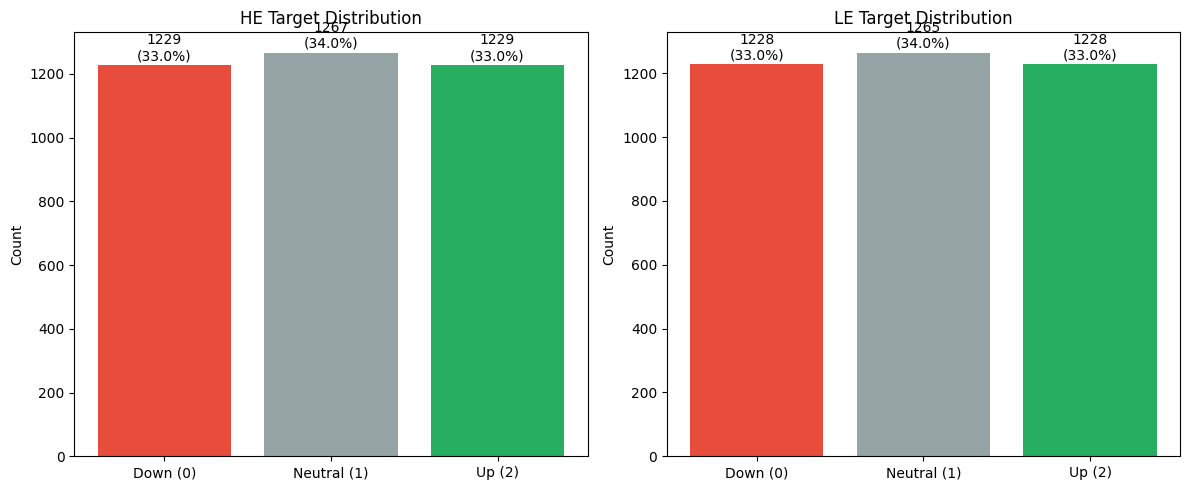

In [60]:
# Visualize combined target distribution
if TASK == 'classification':
    fig, axes = plt.subplots(1, len(TICKERS), figsize=(6*len(TICKERS), 5))
    if len(TICKERS) == 1:
        axes = [axes]

    for ticker, ax in zip(TICKERS, axes):
        model = multi_asset.get_model(ticker)
        target_counts = model.target_data.value_counts().sort_index()

        bars = ax.bar(
            ['Down (0)', 'Neutral (1)', 'Up (2)'][:len(target_counts)],
            target_counts.values,
            color=['#e74c3c', '#95a5a6', '#27ae60']
        )
        ax.set_ylabel('Count')
        ax.set_title(f'{ticker} Target Distribution')

        for bar, count in zip(bars, target_counts.values):
            pct = count/len(model.target_data)*100
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'{count}\n({pct:.1f}%)', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

## 4. Define Optuna Objective

In [61]:
from CTAFlow.models.deep_learning.multi_branch.dual_model import MultiAssetWSPR
from CTAFlow.models.deep_learning.training.loss import ProfitWeightedCE

def create_dataloaders(window_size: int, batch_size: int, val_split: float = 0.2):
    """Create multi-ticker windowed dataloaders."""
    train_loader, val_loader = multi_asset.get_loaders(
        tickers=TICKERS,
        mode='concat',
        use_wspr=True,
        ticker_id_map=TICKER_ID_MAP,
        asset_class_id_map=ASSET_CLASS_ID_MAP,
        asset_subclass_id_map=ASSET_SUBCLASS_ID_MAP,
        val_split=True,
        val_split_size=val_split,
        windowed=True,
        window_days=window_size,
        batch_size=batch_size,
        shuffle_train=True,
        num_workers=0,
        include_spatial=True,
        use_rasterized=True,
        add_raw_returns=True,
        verbose=False,
    )
    return train_loader, val_loader


def train_epoch(model, loader, criterion, optimizer, device, task):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch in loader:
        summary_days, profile_days, raster_recent, seq_recent, seq_lens, targets, raw_returns, meta = batch

        summary_days = summary_days.to(device)
        profile_days = profile_days.to(device)
        raster_recent = raster_recent.to(device)
        seq_recent = seq_recent.to(device)
        seq_lens = seq_lens.to(device)
        targets = targets.to(device)
        meta = {k: v.to(device) for k, v in meta.items()}
        returns = raw_returns.to(device)

        if task == 'classification':
            targets = targets.long()

        optimizer.zero_grad()
        outputs = model(summary_days, profile_days, raster_recent, seq_recent, seq_lens, meta)

        loss = criterion(outputs, targets, returns) if task == 'classification' else criterion(outputs.squeeze(), targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_samples += targets.size(0)

        if task == 'classification':
            _, predicted = outputs.max(1)
            total_correct += predicted.eq(targets).sum().item()

    avg_loss = total_loss / len(loader)
    acc = 100.0 * total_correct / total_samples if total_samples > 0 else 0
    return avg_loss, acc

def evaluate(model, loader, criterion, device, task, transaction_cost=0.0):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    total_pnl = 0.0

    # Directional metrics
    dir_correct = 0
    dir_attempts = 0
    confidences = []

    with torch.no_grad():
        for batch in loader:
            # MULTI-ASSET UNPACKING
            # inputs: summary, profile, raster, seq, meta
            # labels: targets, raw_returns
            summary_days, profile_days, raster_recent, seq_recent, seq_lens, targets, raw_returns, meta = batch
# 2. Move to device
            summary, profile, raster, seq, seq_lens = [x.to(device) for x in [summary, profile, raster, seq, seq_lens]]
            targets = targets.to(device).long()
            raw_returns = raw_returns.to(device)
            meta = {k: v.to(device) for k, v in meta.items()}
            if task == 'classification':
                targets = targets.long()

            # Pass ALL inputs including Meta to the model
            outputs = model(summary, profile, raster, seq, seq_lens, meta)

            # --- ProfitWeightedCE Logic ---
            if isinstance(criterion, ProfitWeightedCE):
                loss = criterion(outputs, targets, returns=raw_returns)
            else:
                loss = criterion(outputs, targets)

            total_loss += loss.item()
            total_samples += targets.size(0)

            if task == 'classification':
                # Accuracy & PnL
                _, predicted = outputs.max(1)
                total_correct += predicted.eq(targets).sum().item()

                probs = torch.softmax(outputs, dim=-1)
                # Position logic: Long Prob - Short Prob
                position = probs[:, 2] - probs[:, 0]
                pnl = position * raw_returns - transaction_cost * position.abs()
                total_pnl += pnl.sum().item()

                # Directional Accuracy Logic
                is_trade = (predicted != 1) # Non-flat predictions
                if is_trade.any():
                    dir_attempts += is_trade.sum().item()
                    # Predicted Long (2) and return > 0 OR Predicted Short (0) and return < 0
                    correct_mask =( ((predicted == 2) & (raw_returns > 0)) | ((predicted == 0) & (raw_returns < 0)))
                    dir_correct += ().sum().item()

    avg_loss = total_loss / len(loader)


    # Using max_weight from criterion for the composite score scaling
    acc = 100.0 * total_correct / total_samples if total_samples > 0 else 0
    avg_pnl = total_pnl / total_samples if total_samples > 0 else 0
    dir_acc = (100.0 * dir_correct / dir_attempts) if dir_attempts > 0 else 0.0


    return avg_loss, avg_pnl, acc, dir_acc

In [62]:
def objective(trial: optuna.Trial) -> float:
    # --- Exact Hyperparameters from your Snippet ---
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    window_size = trial.suggest_int('window_size', 3, 15, step=3)
    d_model = trial.suggest_categorical('d_model', [32, 64])
    meta_hidden = trial.suggest_categorical('meta_hidden', [32, 64])

    sum_lstm_hidden = trial.suggest_categorical('lstm_hidden', [32, 64, 128])
    prof_lstm_hidden = trial.suggest_categorical('prof_lstm', [32, 64, 128])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 5e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
    transaction_cost = 0.003
    max_class_weight = 34
    get_score = lambda pnl, acc: pnl *  ((acc-max_class_weight) if (acc-max_class_weight)>1.0 else (acc/pnl))

    # --- ProfitWeightedCE Hyperparameters ---
    profit_scale = trial.suggest_float('profit_scale', 5.0, 100.0, log=True)
    direction_penalty = trial.suggest_float('direction_penalty', 1.0, 4.0)
    min_weight = trial.suggest_float('min_weight', 0.1, 0.5)
    max_weight = trial.suggest_float('max_weight', 5.0, 20.0)

    # --- Setup Dataloaders ---
    try:
        # Assuming create_dataloaders is updated for multi-asset alignment
        train_loader, val_loader = create_dataloaders(
           window_size=window_size, batch_size=batch_size, val_split=0.2
        )
    except Exception as e:
        print(f"Dataloader failed: {e}")
        return -1e9

    # --- MultiAssetWSPR Initialization ---
    model =     model = MultiAssetWSPR(
        f_sum=dims.summary_dim,
        f_profile=dims.profile_channels,
        f_raster=dims.raster_channels,
        f_seq=dims.seq_dim - 1,
        d_model=d_model,
        sum_lstm_hidden=sum_lstm_hidden,
        prof_lstm_hidden=prof_lstm_hidden,
        meta_hidden=meta_hidden,
        n_tickers=len(TICKERS),
        n_asset_classes=len(set(ASSET_CLASS_ID_MAP.values())),
        n_asset_subclasses=len(set(ASSET_SUBCLASS_ID_MAP.values())),
        task=TASK,
        num_classes=NUM_CLASSES if TASK == 'classification' else 1,
        dropout=dropout,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    # --- ProfitWeightedCE Criterion ---
    criterion = ProfitWeightedCE(
        profit_scale=profit_scale,
        min_weight=min_weight,
        max_weight=max_weight,
        direction_penalty=direction_penalty
    ).to(device)

    best_score = -1e9
    patience = 10
    patience_counter = 0

    for epoch in range(20):
        model.train()
        # Internal Training Loop for Multi-Asset
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, "classification")

        # Evaluation
        val_loss, val_pnl, val_acc, val_dir_acc = evaluate(
            model, val_loader, criterion, device, 'classification', epoch, transaction_cost=transaction_cost
        )

        val_score = get_score(val_pnl, val_acc)




        # LOGGING EVERY 5 EPOCHS
        if (epoch + 1) % 5 == 0:
            print(f" E{epoch+1} | Val PnL: {val_pnl:.6f} | Val Composite: {val_score:.4f} | Acc: {val_acc:.2f}% | Dir_acc: {val_dir_acc:.2f}%")

        scheduler.step()

        # Track Score and Save Metrics
        if val_score > best_score:
            best_score = val_score
            patience_counter = 0
            trial.set_user_attr("final_pnl", val_pnl)
            trial.set_user_attr("final_score", val_score)
            trial.set_user_attr("final_acc", val_acc)
            trial.set_user_attr("final_dir_acc", val_dir_acc)
        else:
            patience_counter += 1

        trial.report(val_score, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        if patience_counter >= patience:
            break

    return best_score

## 5. Run Optuna Optimization

In [63]:
# Optimization settings
N_TRIALS = 30
STUDY_NAME = f"multi_asset_{'_'.join(TICKERS)}_{TASK}"

# Create study
direction = 'maximize' if TASK == 'classification' else 'minimize'

study = optuna.create_study(
    study_name=STUDY_NAME,
    direction=direction,
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=5),
)

print(f"Starting optimization: {N_TRIALS} trials")
print(f"Study name: {STUDY_NAME}")
print(f"Tickers: {', '.join(TICKERS)}")
print(f"Direction: {direction}")
print(f"Task: {TASK}")
print("-" * 50)

[I 2026-02-03 01:04:57,620] A new study created in memory with name: multi_asset_HE_LE_classification


Starting optimization: 30 trials
Study name: multi_asset_HE_LE_classification
Tickers: HE, LE
Direction: maximize
Task: classification
--------------------------------------------------


In [64]:
# Run optimization
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
)

  0%|          | 0/30 [00:00<?, ?it/s]

[W 2026-02-03 01:05:21,059] Trial 0 failed with parameters: {'dropout': 0.249816047538945, 'window_size': 15, 'd_model': 32, 'meta_hidden': 32, 'lstm_hidden': 64, 'prof_lstm': 128, 'batch_size': 16, 'learning_rate': 8.66133373527314e-05, 'weight_decay': 0.0004059611610484307, 'profit_scale': 24.082072654535423, 'direction_penalty': 2.2958350559263474, 'min_weight': 0.21649165607921678, 'max_weight': 14.177793420835693} because of the following error: ValueError('not enough values to unpack (expected 8, got 7)').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-2626027708.py", line 69, in objective
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, "classification")
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

ValueError: not enough values to unpack (expected 8, got 7)

In [ ]:
# Best trial results
best_trial = study.best_trial
print(f"\nBest trial:")
print(f"  Value: {best_trial.value:.4f}")
print(f"  Params:")

best_params = best_trial.params
for key, value in best_params.items():
    print(f"    {key}: {value}")

# Save best params
best_params['best_value'] = best_trial.value
best_params['tickers'] = TICKERS
best_params['task'] = TASK

save_name = f"{'_'.join(TICKERS)}_best_params.json"
with open(RESULTS_PATH / save_name, 'w') as f:
    json.dump(best_params, f, indent=2)

print(f"\nBest params saved to: {RESULTS_PATH / save_name}")

In [ ]:
# Save study artifacts
import joblib
import pandas as pd

prefix = f"{'_'.join(TICKERS)}_wspr_optuna"

# Save study object
joblib.dump(study, RESULTS_PATH / f"{prefix}_study.pkl")

# Save trials dataframe
df = study.trials_dataframe()
df.to_csv(RESULTS_PATH / f"{prefix}_all_trials.csv", index=False)

print(f"Study saved:")
print(f"  - {prefix}_study.pkl")
print(f"  - {prefix}_all_trials.csv")

## 6. Visualization

In [ ]:
# Optimization history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

trials_df = study.trials_dataframe()
valid_trials = trials_df[trials_df['state'] == 'COMPLETE']

# 1. Optimization history
ax = axes[0, 0]
ax.plot(valid_trials.index, valid_trials['value'], 'b-o', alpha=0.6, label='Trial value')
ax.axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
ax.set_xlabel('Trial')
ylabel = 'Accuracy (%)' if TASK == 'classification' else 'Negative MSE'
ax.set_ylabel(ylabel)
ax.set_title('Optimization History')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Parameter importance
ax = axes[0, 1]
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values = list(importances.values())
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(params)))
    ax.barh(params, values, color=colors)
    ax.set_xlabel('Importance')
    ax.set_title('Hyperparameter Importance')
    ax.grid(True, alpha=0.3, axis='x')
except:
    ax.text(0.5, 0.5, 'Not enough trials\nfor importance analysis',
            ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Hyperparameter Importance')

# 3. Learning rate vs performance
ax = axes[1, 0]
if 'params_learning_rate' in valid_trials.columns:
    ax.scatter(valid_trials['params_learning_rate'], valid_trials['value'],
               c=valid_trials.index, cmap='viridis', alpha=0.7, s=100)
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Performance')
    ax.set_title('Learning Rate vs Performance')
    ax.grid(True, alpha=0.3)

# 4. d_model vs performance
ax = axes[1, 1]
if 'params_d_model' in valid_trials.columns:
    d_models = sorted(valid_trials['params_d_model'].unique())
    data_by_d = [valid_trials[valid_trials['params_d_model'] == d]['value'].values for d in d_models]
    bp = ax.boxplot(data_by_d, positions=range(len(d_models)), patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set2(np.linspace(0, 1, len(d_models)))):
        patch.set_facecolor(color)
    ax.set_xticks(range(len(d_models)))
    ax.set_xticklabels([str(int(d)) for d in d_models])
    ax.set_xlabel('d_model')
    ax.set_ylabel('Performance')
    ax.set_title('Model Size vs Performance')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f"Multi-Asset WSPR Optimization ({', '.join(TICKERS)})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH / f"{prefix}_results.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Train Final Model with Best Parameters

In [ ]:
# Extract best parameters
best = best_params

print("Training final model with best parameters:")
for k, v in best.items():
    if k not in ['best_value', 'tickers', 'task']:
        print(f"  {k}: {v}")

In [ ]:
# Create final dataloaders
train_loader, val_loader = create_dataloaders(
    window_size=best['window_size'],
    batch_size=best['batch_size'],
    val_split=0.2,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

In [ ]:
# Create final model
final_model = MultiAssetWSPR(
    f_sum=dims.summary_dim,
    f_profile=dims.profile_channels,
    f_raster=dims.raster_channels,
    f_seq=dims.seq_dim - 1,
    d_model=best['d_model'],
    sum_lstm_hidden=best['sum_lstm_hidden'],
    prof_lstm_hidden=best['prof_lstm_hidden'],
    meta_hidden=best['meta_hidden'],
    n_tickers=len(TICKERS),
    n_asset_classes=len(set(ASSET_CLASS_ID_MAP.values())),
    n_asset_subclasses=len(set(ASSET_SUBCLASS_ID_MAP.values())),
    task=TASK,
    num_classes=NUM_CLASSES if TASK == 'classification' else 1,
    dropout=best['dropout'],
).to(device)

print(f"\nModel parameters: {sum(p.numel() for p in final_model.parameters()):,}")

In [ ]:
# Training settings
NUM_EPOCHS = 30

if TASK == 'classification':
    criterion = ProfitWeightedCE(
        profit_scale=best['profit_scale'],
        min_weight=best['min_weight'],
        max_weight=best['max_weight'],
        direction_penalty=best['direction_penalty'],
    )
else:
    criterion = nn.MSELoss()

optimizer = optim.AdamW(
    final_model.parameters(),
    lr=best['learning_rate'],
    weight_decay=best['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=best['learning_rate'] * 0.001
)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_metric': [], 'val_metric': [],
    'lr': []
}

best_metric = float('-inf') if TASK == 'classification' else float('inf')
best_state = None

print(f"\nStarting final training for {NUM_EPOCHS} epochs...")
print("=" * 60)

In [ ]:
# Training loop
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(final_model, train_loader, criterion, optimizer, device, TASK)
    val_loss, val_acc = evaluate(final_model, val_loader, criterion, device, TASK)

    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_metric'].append(train_acc if TASK == 'classification' else train_loss)
    history['val_metric'].append(val_acc if TASK == 'classification' else val_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Check for best model
    current_metric = val_acc if TASK == 'classification' else -val_loss
    is_best = (TASK == 'classification' and current_metric > best_metric) or \
              (TASK == 'regression' and -val_loss > best_metric)

    if is_best:
        best_metric = current_metric
        best_state = final_model.state_dict().copy()

    # Log progress
    log_msg = f"Epoch {epoch+1:02}/{NUM_EPOCHS} | "
    log_msg += f"Train: {train_loss:.4f} | Val: {val_loss:.4f}"
    if TASK == 'classification':
        log_msg += f" | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%"
    if is_best:
        log_msg += " [BEST]"
    print(log_msg)

print("=" * 60)
print("Training complete!")

In [ ]:
# Load best model state
if best_state:
    final_model.load_state_dict(best_state)
    print("Loaded best model state")

In [ ]:
# Plot final training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
ax = axes[0]
ax.plot(history['train_loss'], label='Train', alpha=0.8)
ax.plot(history['val_loss'], label='Validation', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Metric
ax = axes[1]
ax.plot(history['train_metric'], label='Train', alpha=0.8)
ax.plot(history['val_metric'], label='Validation', alpha=0.8)
ax.set_xlabel('Epoch')
ylabel = 'Accuracy (%)' if TASK == 'classification' else 'Loss'
ax.set_ylabel(ylabel)
ax.set_title(f'Training & Validation {ylabel}')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[2]
ax.plot(history['lr'], 'g-', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

title = f"Multi-Asset WSPR Training ({', '.join(TICKERS)})"
plt.suptitle(title, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH / f"{prefix}_training_history.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Final Model

In [ ]:
# Save model
model_path = RESULTS_PATH / f"{prefix}_best_model.pth"
torch.save({
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_metric': best_metric,
    'params': best,
    'tickers': TICKERS,
    'ticker_id_map': TICKER_ID_MAP,
    'asset_class_id_map': ASSET_CLASS_ID_MAP,
    'asset_subclass_id_map': ASSET_SUBCLASS_ID_MAP,
    'dims': {
        'summary_dim': dims.summary_dim,
        'seq_dim': dims.seq_dim,
        'profile_shape': dims.profile_shape,
        'raster_shape': dims.raster_shape,
    },
    'task': TASK,
    'num_classes': NUM_CLASSES,
    'history': history,
}, model_path)

print(f"Model saved to: {model_path}")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_PATH / f"{prefix}_training_history.csv", index=False)

# Summary
print(f"\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"\nArtifacts saved to: {RESULTS_PATH}")
print(f"  - {prefix}_best_model.pth (model checkpoint)")
print(f"  - {'_'.join(TICKERS)}_best_params.json (best hyperparameters)")
print(f"  - {prefix}_study.pkl (optuna study)")
print(f"  - {prefix}_all_trials.csv (all trials)")
print(f"  - {prefix}_results.png (optimization visualization)")
print(f"  - {prefix}_training_history.png (training curves)")
print(f"  - {prefix}_training_history.csv (training data)")